### Working On Titanic Dataset Without Using Pipelines 

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier

In [2]:
df=pd.read_csv("F:\Machine Learning 2026\Pandas\Datasets\Titanic.csv")

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\lenovo\AppData\Local\Temp\ipykernel_5520\425119279.py:1: SyntaxWarning: invalid escape sequence '\M'
  df=pd.read_csv("F:\Machine Learning 2026\Pandas\Datasets\Titanic.csv")


In [3]:
df.sample(4,random_state=42)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S


In [4]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

In [5]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [6]:
#step 1 --> Train test Split 
X_train,X_test,y_train,y_test=train_test_split(df.iloc[:,1:],
                                               df['Survived'],
                                               test_size=0.2,
                                               random_state=42)

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

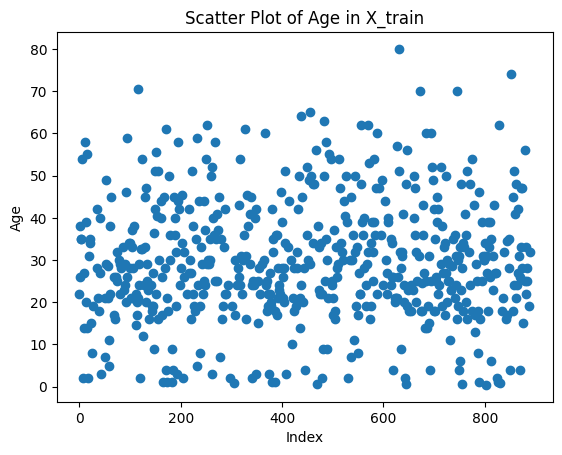

In [8]:
plt.scatter(X_train.index, X_train['Age'])
plt.xlabel('Index')
plt.ylabel('Age')
plt.title('Scatter Plot of Age in X_train')
plt.show()

In [9]:
X_train['Embarked'].nunique()

3

In [10]:
#Apply Imputation 
si_age=SimpleImputer(strategy='mean')
si_embarked=SimpleImputer(strategy='most_frequent')
#Training Data Ma imputer lagako 
X_train_age=si_age.fit_transform(X_train[['Age']])
X_train_embarked=si_embarked.fit_transform(X_train[['Embarked']])

#Testing data ma only transform lagaune   
X_test_age=si_age.transform(X_test[['Age']])
X_test_embarked=si_embarked.transform(X_test[['Embarked']])

In [11]:
X_train_embarked.shape

(712, 1)

In [12]:
#Applying One Hot Encoding On Nominal Data 
ohe_sex=OneHotEncoder(sparse_output=False,handle_unknown='ignore')
ohe_embarked=OneHotEncoder(sparse_output=False,handle_unknown='ignore')

X_train_sex=ohe_sex.fit_transform(X_train[['Sex']])
X_train_embarked=ohe_embarked.fit_transform(X_train_embarked)

X_test_sex=ohe_sex.transform(X_test[['Sex']])
X_test_embarked=ohe_embarked.transform(X_test_embarked)

In [13]:
X_train_embarked.shape

(712, 3)

Since We are using decision Tree we dont have to drop the first column to tackle multicolinearity 

In [14]:
X_train.head(2)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,male,45.5,0,0,28.5,S
733,2,male,23.0,0,0,13.0,S


In [15]:
X_train_rem=X_train.drop(columns=['Sex','Age','Embarked'])

In [16]:
X_train_embarked.shape

(712, 3)

In [17]:
X_test_rem=X_test.drop(columns=['Sex','Age','Embarked'])

In [19]:
X_train_transform=np.concatenate((X_train_rem,X_train_age,X_train_sex,X_train_embarked),axis=1)

In [21]:
X_test_transform=np.concatenate((X_test_rem,X_test_age,X_test_sex,X_test_embarked),axis=1)

In [22]:
clf=DecisionTreeClassifier()
clf.fit(X_train_transform,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [23]:
y_pred=clf.predict(X_test_transform)

In [24]:
from sklearn.metrics import accuracy_score

In [25]:
accuracy_score(y_test,y_pred)

0.7821229050279329

In [26]:
import pickle


In [31]:
pickle.dump(ohe_sex,open('F:\Machine Learning 2026\models/ohe_sex.pkl','wb'))
pickle.dump(ohe_embarked,open('F:\Machine Learning 2026\models/ohe_embarked.pkl','wb'))
pickle.dump(clf,open('F:\Machine Learning 2026\models/clf.pkl','wb'))

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:2: SyntaxWarning: invalid escape sequence '\M'
<>:3: SyntaxWarning: invalid escape sequence '\M'
C:\Users\lenovo\AppData\Local\Temp\ipykernel_5520\4007272370.py:1: SyntaxWarning: invalid escape sequence '\M'
  pickle.dump(ohe_sex,open('F:\Machine Learning 2026\models/ohe_sex.pkl','wb'))
C:\Users\lenovo\AppData\Local\Temp\ipykernel_5520\4007272370.py:2: SyntaxWarning: invalid escape sequence '\M'
  pickle.dump(ohe_embarked,open('F:\Machine Learning 2026\models/ohe_embarked.pkl','wb'))
C:\Users\lenovo\AppData\Local\Temp\ipykernel_5520\4007272370.py:3: SyntaxWarning: invalid escape sequence '\M'
  pickle.dump(clf,open('F:\Machine Learning 2026\models/clf.pkl','wb'))
